# 05. YOLO11n ONNX 로컬 검증

이 노트북의 목적은 **Pi에 올리기 전, 선택된 YOLO11n aug ONNX 모델이 로컬에서 정상적으로 동작하는지 확인**하는 것임.

이미 Roboflow 라벨링과 Colab 학습 결과를 통해 `field2_light_aug_v2_yolo11n` 모델을 1차 선택했음. 이제 여기서는 모델 성능을 다시 길게 평가하는 것이 아니라, 아래를 확인함.

1. ONNX Runtime에서 모델이 정상 로드되는지 확인함.
2. 모델 입력/출력 shape을 확인함.
3. Pi 카메라 원본 해상도 `1296 x 972` 프레임을 YOLO 입력 `640 x 640`으로 letterbox 전처리하는 흐름을 확인함.
4. field2 원본 표지판 이미지에서 실제 detection이 나오는지 시각적으로 확인함.
5. confidence threshold 후보를 대략적으로 본 뒤, Pi 실험에서 쓸 초기값을 정함.
6. 로컬 CPU 기준 latency를 참고값으로 측정함.

중요: 최종 latency 판단은 반드시 Pi에서 다시 해야 함. 이 노트북의 latency는 **로컬 sanity check**임.

In [1]:
from pathlib import Path
import json
import time
import math
import random
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import onnx
    print('onnx OK', onnx.__version__)
except Exception as e:
    print('onnx FAIL', type(e).__name__, e)

try:
    import onnxruntime as ort
    print('onnxruntime OK', ort.__version__)
except Exception as e:
    print('onnxruntime FAIL', type(e).__name__, e)

print('cv2', cv2.__version__)
print('numpy', np.__version__)

onnx OK 1.21.0
onnxruntime OK 1.23.2
cv2 4.13.0
numpy 2.2.6


## 1. 경로와 모델 선택

이번 실험에서 Pi에 올릴 1차 후보는 aug 버전임.

- primary: `sign_yolo11n_field2_light_aug_best.onnx`
- fallback: `sign_yolo11n_field2_clean_best.onnx`

YOLO 모델은 CLRKDNet 주행모델처럼 `cut_height`, `sample_y`와 직접 묶여 있지는 않음. 원본 프레임을 YOLO 입력 크기인 `640 x 640`으로 letterbox해서 넣고, 결과 박스 좌표를 다시 원본 좌표계로 복원하는 구조임.

In [2]:
PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '07_sign_detection_yolo'
MODEL_DIR = PROJECT_ROOT / '20_shared_assets' / 'models' / 'sign_yolo11n_field2_v1'
SELECTION_JSON = MODEL_DIR / 'sign_yolo11n_field2_v1_selection.json'

FIELD2_SIGN_ROOT = PROJECT_ROOT / '10_experiments' / '04_field2_map_lab' / 'field2_experiment' / 'data' / '20260501_field2' / 'raw' / '06_sign_capture_drive'
OUT_DIR = EXP_ROOT / 'review_outputs' / '05_yolo11n_onnx_local_validation'
OVERLAY_DIR = OUT_DIR / 'overlays'
TABLE_DIR = OUT_DIR / 'tables'
for p in [OUT_DIR, OVERLAY_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

selection = json.loads(SELECTION_JSON.read_text(encoding='utf-8'))
CLASS_NAMES = selection['classes']
PRIMARY_ONNX = MODEL_DIR / selection['selected_model']
FALLBACK_ONNX = MODEL_DIR / selection['fallback_model']
INPUT_SIZE = int(selection.get('input_size', 640))

print('MODEL_DIR:', MODEL_DIR)
print('PRIMARY_ONNX:', PRIMARY_ONNX, PRIMARY_ONNX.exists(), PRIMARY_ONNX.stat().st_size if PRIMARY_ONNX.exists() else None)
print('FALLBACK_ONNX:', FALLBACK_ONNX, FALLBACK_ONNX.exists(), FALLBACK_ONNX.stat().st_size if FALLBACK_ONNX.exists() else None)
print('FIELD2_SIGN_ROOT:', FIELD2_SIGN_ROOT, FIELD2_SIGN_ROOT.exists())
print('classes:', CLASS_NAMES)
print('input_size:', INPUT_SIZE)

MODEL_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1
PRIMARY_ONNX: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1\sign_yolo11n_field2_light_aug_best.onnx True 10608002
FALLBACK_ONNX: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1\sign_yolo11n_field2_clean_best.onnx True 10607998
FIELD2_SIGN_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2\raw\06_sign_capture_drive True
classes: ['horn', 'left', 'right', 'speed_20', 'stop', 'straight']
input_size: 640


## 2. ONNX 모델 구조 확인

Ultralytics YOLO ONNX는 보통 입력이 `1 x 3 x 640 x 640`이고, 출력은 `1 x (4 + num_classes) x N` 또는 `1 x N x (4 + num_classes)` 형태로 나옴.

우리 클래스는 6개이므로 출력 채널은 보통 `4 + 6 = 10`이 됨. 앞 4개는 bbox 좌표, 뒤 6개는 class score로 해석함.

In [3]:
onnx_model = onnx.load(str(PRIMARY_ONNX))
onnx.checker.check_model(onnx_model)
print('onnx checker: OK')

session_options = ort.SessionOptions()
session_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
session = ort.InferenceSession(str(PRIMARY_ONNX), sess_options=session_options, providers=['CPUExecutionProvider'])

input_meta = session.get_inputs()[0]
output_meta = session.get_outputs()
print('input name:', input_meta.name)
print('input shape:', input_meta.shape)
print('input type:', input_meta.type)
for i, out in enumerate(output_meta):
    print(f'output[{i}] name={out.name} shape={out.shape} type={out.type}')

onnx checker: OK
input name: images
input shape: [1, 3, 640, 640]
input type: tensor(float)
output[0] name=output0 shape=[1, 10, 8400] type=tensor(float)


## 3. YOLO 전처리와 후처리 함수

YOLO 쪽 전처리는 `letterbox`가 핵심임.

- 원본 비율을 유지한 채 `640 x 640` 안에 들어가도록 resize함.
- 남는 영역은 padding으로 채움.
- 추론 후 박스 좌표는 padding과 scale을 역으로 적용해서 원본 이미지 좌표로 되돌림.

이 구조 덕분에 카메라 원본이 `1296 x 972`여도 모델 입력 `640 x 640`과 충돌하지 않음.

In [4]:
def read_rgb(path: Path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError(f'failed to read image: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def letterbox_rgb(image_rgb, new_shape=640, color=(114, 114, 114)):
    h, w = image_rgb.shape[:2]
    if isinstance(new_shape, int):
        new_shape = (new_shape, new_shape)
    new_h, new_w = new_shape
    scale = min(new_w / w, new_h / h)
    resized_w = int(round(w * scale))
    resized_h = int(round(h * scale))
    pad_w = new_w - resized_w
    pad_h = new_h - resized_h
    pad_left = int(round(pad_w / 2 - 0.1))
    pad_right = int(round(pad_w / 2 + 0.1))
    pad_top = int(round(pad_h / 2 - 0.1))
    pad_bottom = int(round(pad_h / 2 + 0.1))

    resized = cv2.resize(image_rgb, (resized_w, resized_h), interpolation=cv2.INTER_LINEAR)
    padded = cv2.copyMakeBorder(resized, pad_top, pad_bottom, pad_left, pad_right,
                                cv2.BORDER_CONSTANT, value=color)
    meta = {
        'orig_w': w, 'orig_h': h,
        'scale': scale,
        'pad_left': pad_left, 'pad_top': pad_top,
        'resized_w': resized_w, 'resized_h': resized_h,
        'input_w': new_w, 'input_h': new_h,
    }
    return padded, meta


def preprocess_yolo(image_rgb, input_size=640):
    padded, meta = letterbox_rgb(image_rgb, input_size)
    tensor = padded.astype(np.float32) / 255.0
    tensor = np.transpose(tensor, (2, 0, 1))[None, ...]
    return tensor, padded, meta


def xywh_to_xyxy(boxes):
    x, y, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    return np.stack([x - w / 2, y - h / 2, x + w / 2, y + h / 2], axis=1)


def rescale_boxes_to_original(xyxy, meta):
    boxes = xyxy.copy().astype(np.float32)
    boxes[:, [0, 2]] -= meta['pad_left']
    boxes[:, [1, 3]] -= meta['pad_top']
    boxes[:, :4] /= meta['scale']
    boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, meta['orig_w'] - 1)
    boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, meta['orig_h'] - 1)
    return boxes


def nms_numpy(boxes, scores, iou_threshold=0.45):
    if len(boxes) == 0:
        return []
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(int(i))
        if order.size == 1:
            break
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter_w = np.maximum(0, xx2 - xx1)
        inter_h = np.maximum(0, yy2 - yy1)
        inter = inter_w * inter_h
        union = areas[i] + areas[order[1:]] - inter + 1e-9
        iou = inter / union
        order = order[1:][iou <= iou_threshold]
    return keep


def normalize_yolo_output(raw_output):
    # Accept [1, 10, 8400] or [1, 8400, 10]. Return [N, 10].
    pred = raw_output[0] if isinstance(raw_output, (list, tuple)) else raw_output
    pred = np.asarray(pred)
    if pred.ndim == 3:
        pred = pred[0]
    if pred.shape[0] == 4 + len(CLASS_NAMES):
        pred = pred.T
    elif pred.shape[-1] == 4 + len(CLASS_NAMES):
        pass
    else:
        raise ValueError(f'unexpected YOLO output shape: {pred.shape}')
    return pred.astype(np.float32)


def postprocess_yolo(raw_output, meta, conf_threshold=0.35, iou_threshold=0.45, max_det=20):
    pred = normalize_yolo_output(raw_output)
    boxes_xywh = pred[:, :4]
    class_scores = pred[:, 4:4 + len(CLASS_NAMES)]
    class_ids = class_scores.argmax(axis=1)
    scores = class_scores.max(axis=1)
    mask = scores >= conf_threshold
    boxes_xywh = boxes_xywh[mask]
    scores = scores[mask]
    class_ids = class_ids[mask]
    if len(scores) == 0:
        return []

    boxes_xyxy_input = xywh_to_xyxy(boxes_xywh)
    boxes_xyxy_orig = rescale_boxes_to_original(boxes_xyxy_input, meta)

    final = []
    for cls_id in sorted(set(class_ids.tolist())):
        idx = np.where(class_ids == cls_id)[0]
        keep_local = nms_numpy(boxes_xyxy_orig[idx], scores[idx], iou_threshold=iou_threshold)
        for k in keep_local:
            i = idx[k]
            final.append({
                'class_id': int(class_ids[i]),
                'class_name': CLASS_NAMES[int(class_ids[i])],
                'confidence': float(scores[i]),
                'box_xyxy': boxes_xyxy_orig[i].tolist(),
            })
    final.sort(key=lambda d: d['confidence'], reverse=True)
    return final[:max_det]


def run_onnx_on_image(session, image_rgb, conf_threshold=0.35, iou_threshold=0.45):
    tensor, padded, meta = preprocess_yolo(image_rgb, INPUT_SIZE)
    raw = session.run(None, {session.get_inputs()[0].name: tensor})
    dets = postprocess_yolo(raw, meta, conf_threshold=conf_threshold, iou_threshold=iou_threshold)
    return dets, padded, meta, raw

print('pre/postprocess functions ready')

pre/postprocess functions ready


## 4. 전처리 sanity check

여기서는 field2 원본 이미지 1장을 골라서 원본 프레임과 YOLO 입력 프레임을 같이 확인함.

원본은 `1296 x 972`이고, YOLO 입력은 letterbox된 `640 x 640`이어야 함.

field2 sign images: 2542
first: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2\raw\06_sign_capture_drive\horn\20260501_122048_06_sign_capture_drive_horn_09997.jpg
sample_path: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2\raw\06_sign_capture_drive\right\20260501_121219_06_sign_capture_drive_right_00941.jpg
raw shape: (972, 1296, 3)
yolo input image shape: (640, 640, 3)
tensor shape: (1, 3, 640, 640)
letterbox meta: {'orig_w': 1296, 'orig_h': 972, 'scale': 0.49382716049382713, 'pad_left': 0, 'pad_top': 80, 'resized_w': 640, 'resized_h': 480, 'input_w': 640, 'input_h': 640}


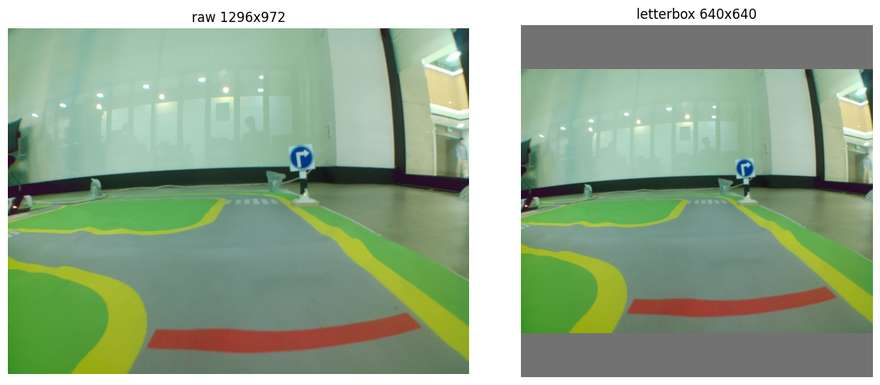

In [5]:
def list_images(root: Path):
    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    return sorted([p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in exts and p.stat().st_size > 0])

all_sign_images = list_images(FIELD2_SIGN_ROOT)
print('field2 sign images:', len(all_sign_images))
print('first:', all_sign_images[0] if all_sign_images else None)

sample_path = all_sign_images[len(all_sign_images)//2]
image_rgb = read_rgb(sample_path)
tensor, padded, meta = preprocess_yolo(image_rgb, INPUT_SIZE)
print('sample_path:', sample_path)
print('raw shape:', image_rgb.shape)
print('yolo input image shape:', padded.shape)
print('tensor shape:', tensor.shape)
print('letterbox meta:', meta)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_rgb)
axes[0].set_title(f'raw {image_rgb.shape[1]}x{image_rgb.shape[0]}')
axes[0].axis('off')
axes[1].imshow(padded)
axes[1].set_title(f'letterbox {INPUT_SIZE}x{INPUT_SIZE}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 5. 샘플 이미지 탐지 시각화

각 클래스 폴더에서 몇 장씩 골라 aug ONNX 모델의 detection 결과를 확인함.

이 단계의 판단 기준은 단순함.

- 표지판 주변에 박스가 제대로 그려지는지
- class가 기대 클래스와 대체로 맞는지
- confidence가 너무 낮지는 않은지
- 배경이나 차선에 이상한 박스가 과하게 뜨지 않는지

In [6]:
def collect_balanced_samples(root: Path, per_class=4, seed=7):
    rng = random.Random(seed)
    rows = []
    for class_name in CLASS_NAMES:
        class_dir = root / class_name
        imgs = list_images(class_dir)
        if not imgs:
            print('missing or empty class dir:', class_dir)
            continue
        if len(imgs) <= per_class:
            chosen = imgs
        else:
            # evenly spaced + deterministic shuffle for a little diversity
            step = max(1, len(imgs) // per_class)
            chosen = imgs[::step][:per_class]
        for p in chosen:
            rows.append({'expected': class_name, 'path': p})
    return pd.DataFrame(rows)

sample_df = collect_balanced_samples(FIELD2_SIGN_ROOT, per_class=4)
print('samples:', len(sample_df))
display(sample_df.assign(path=lambda d: d['path'].astype(str)).head(20))

samples: 24


,expected,path
0,horn,~\02_Projects\University\26-1_Em...
1,horn,~\02_Projects\University\26-1_Em...
2,horn,~\02_Projects\University\26-1_Em...
3,horn,~\02_Projects\University\26-1_Em...
4,left,~\02_Projects\University\26-1_Em...
5,left,~\02_Projects\University\26-1_Em...
6,left,~\02_Projects\University\26-1_Em...
7,left,~\02_Projects\University\26-1_Em...
8,right,~\02_Projects\University\26-1_Em...
9,right,~\02_Projects\University\26-1_Em...


In [7]:
def draw_detections(image_rgb, detections, expected=None):
    canvas = image_rgb.copy()
    for det in detections:
        x1, y1, x2, y2 = map(int, det['box_xyxy'])
        cls = det['class_name']
        conf = det['confidence']
        color = (0, 220, 0) if expected is None or cls == expected else (255, 80, 80)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 3)
        label = f'{cls} {conf:.2f}'
        y_text = max(20, y1 - 8)
        cv2.putText(canvas, label, (x1, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)
    if expected:
        cv2.putText(canvas, f'expected: {expected}', (16, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2, cv2.LINE_AA)
    return canvas

CONF_THRESHOLD = 0.35
IOU_THRESHOLD = 0.45

vis_rows = []
for _, row in sample_df.iterrows():
    img = read_rgb(row['path'])
    dets, _, _, _ = run_onnx_on_image(session, img, conf_threshold=CONF_THRESHOLD, iou_threshold=IOU_THRESHOLD)
    top = dets[0] if dets else None
    vis_rows.append({
        'expected': row['expected'],
        'file': row['path'].name,
        'num_det': len(dets),
        'top_class': top['class_name'] if top else None,
        'top_conf': top['confidence'] if top else None,
    })
    overlay = draw_detections(img, dets, expected=row['expected'])
    out_path = OVERLAY_DIR / f"sample_{row['expected']}_{row['path'].stem}.jpg"
    cv2.imwrite(str(out_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

vis_df = pd.DataFrame(vis_rows)
display(vis_df)
vis_df.to_csv(TABLE_DIR / 'sample_detection_summary.csv', index=False, encoding='utf-8-sig')
print('saved table:', TABLE_DIR / 'sample_detection_summary.csv')
print('saved overlays:', OVERLAY_DIR)

,expected,file,num_det,top_class,top_conf
0,horn,20260501_122048_06_sign_capture_drive_horn_099...,1,horn,0.630654
1,horn,20260501_122123_06_sign_capture_drive_horn_105...,1,horn,0.727011
2,horn,20260501_122215_06_sign_capture_drive_horn_114...,1,horn,0.672378
3,horn,20260501_122251_06_sign_capture_drive_horn_122...,1,horn,0.756280
4,left,20260501_121433_06_sign_capture_drive_left_029...,1,left,0.798003
5,left,20260501_121516_06_sign_capture_drive_left_035...,1,left,0.768756
6,left,20260501_121603_06_sign_capture_drive_left_044...,1,left,0.766468
7,left,20260501_121643_06_sign_capture_drive_left_053...,1,left,0.731236
8,right,20260501_120855_06_sign_capture_drive_right_00...,1,right,0.720628
9,right,20260501_120934_06_sign_capture_drive_right_01...,1,right,0.795281


saved table: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\05_yolo11n_onnx_local_validation\tables\sample_detection_summary.csv
saved overlays: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\05_yolo11n_onnx_local_validation\overlays


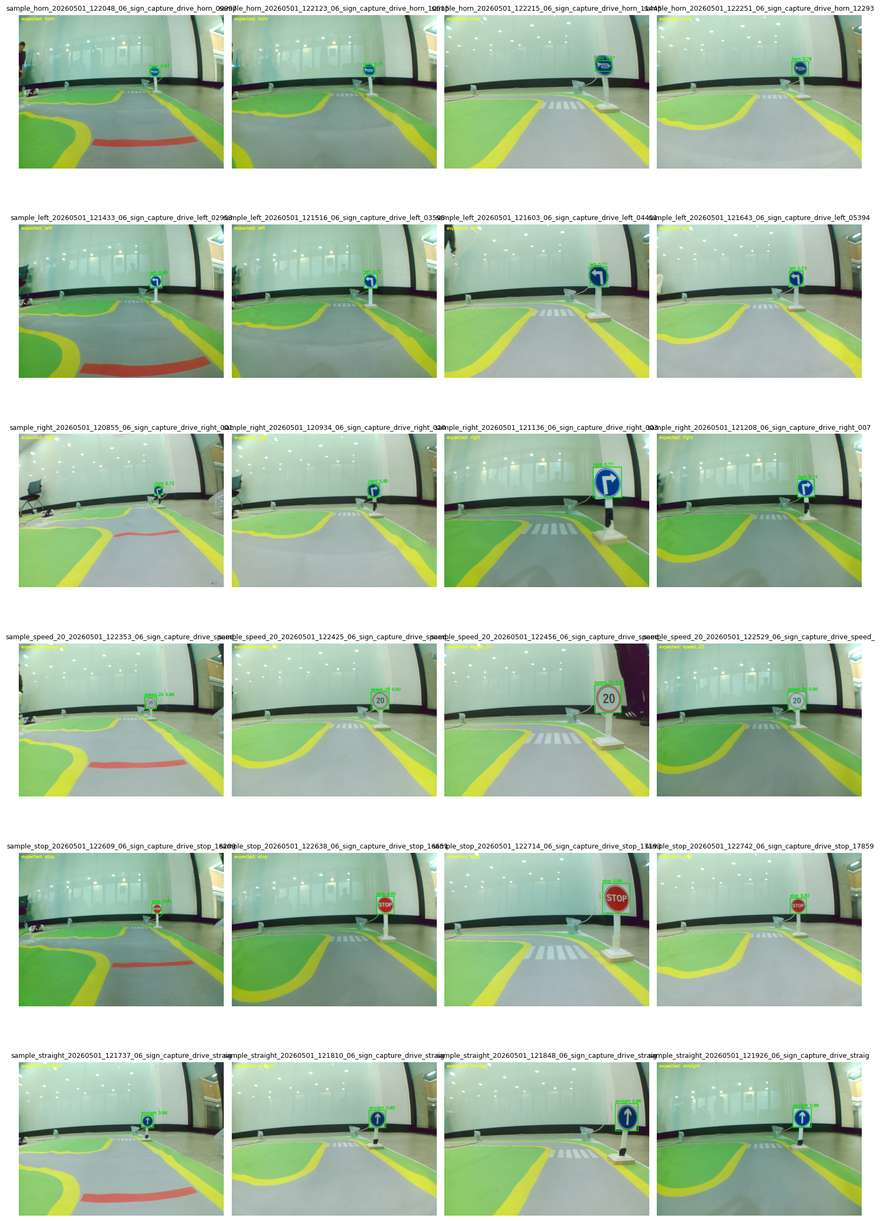

In [8]:
# Grid preview
preview_paths = sorted(OVERLAY_DIR.glob('sample_*.jpg'))[:24]
cols = 4
rows = math.ceil(len(preview_paths) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = np.array(axes).reshape(-1)
for ax, p in zip(axes, preview_paths):
    img = read_rgb(p)
    ax.imshow(img)
    ax.set_title(p.name[:60], fontsize=9)
    ax.axis('off')
for ax in axes[len(preview_paths):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Confidence threshold sweep

실제 통합에서는 표지판을 한 프레임만 보고 바로 제어하지 않을 가능성이 큼. 보통은 `confidence threshold`와 `연속 감지/debounce`를 함께 씀.

그래도 Pi 실험 전 초기 threshold는 정해야 하므로, 여기서는 샘플 이미지 기준으로 threshold별 detection 수와 top-1 class 일치율을 확인함.

초기 후보:

- `0.25`: 더 잘 잡지만 오탐 가능성 증가
- `0.35`: 균형 후보
- `0.45`: 더 보수적
- `0.55+`: 오탐은 줄지만 먼 표지판 누락 가능성 증가

In [9]:
thresholds = [0.25, 0.30, 0.35, 0.45, 0.55, 0.65]
sweep_rows = []
for th in thresholds:
    for _, row in sample_df.iterrows():
        img = read_rgb(row['path'])
        dets, _, _, _ = run_onnx_on_image(session, img, conf_threshold=th, iou_threshold=IOU_THRESHOLD)
        top = dets[0] if dets else None
        sweep_rows.append({
            'threshold': th,
            'expected': row['expected'],
            'file': row['path'].name,
            'num_det': len(dets),
            'top_class': top['class_name'] if top else None,
            'top_conf': top['confidence'] if top else None,
            'top1_match': bool(top and top['class_name'] == row['expected']),
            'missed': len(dets) == 0,
        })

sweep_df = pd.DataFrame(sweep_rows)
summary = sweep_df.groupby('threshold').agg(
    images=('file', 'count'),
    detected_images=('missed', lambda s: int((~s).sum())),
    missed_images=('missed', 'sum'),
    top1_matches=('top1_match', 'sum'),
    mean_num_det=('num_det', 'mean'),
    mean_top_conf=('top_conf', 'mean'),
).reset_index()
summary['top1_match_rate'] = summary['top1_matches'] / summary['images']
summary['detect_rate'] = summary['detected_images'] / summary['images']

display(summary)
sweep_df.to_csv(TABLE_DIR / 'confidence_sweep_detail.csv', index=False, encoding='utf-8-sig')
summary.to_csv(TABLE_DIR / 'confidence_sweep_summary.csv', index=False, encoding='utf-8-sig')
print('saved:', TABLE_DIR / 'confidence_sweep_summary.csv')

,threshold,images,detected_images,missed_images,top1_matches,mean_num_det,mean_top_conf,top1_match_rate,detect_rate
0,0.25,24,24,0,24,1.000000,0.800684,1.000000,1.000000
1,0.30,24,24,0,24,1.000000,0.800684,1.000000,1.000000
2,0.35,24,24,0,24,1.000000,0.800684,1.000000,1.000000
3,0.45,24,24,0,24,1.000000,0.800684,1.000000,1.000000
4,0.55,24,24,0,24,1.000000,0.800684,1.000000,1.000000
5,0.65,24,23,1,23,0.958333,0.808077,0.958333,0.958333


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\05_yolo11n_onnx_local_validation\tables\confidence_sweep_summary.csv


## 7. 로컬 CPU latency 참고 측정

여기서 측정하는 latency는 Pi 성능이 아님. 다만 아래를 구분해서 봄.

- dummy inference: 모델 순수 추론에 가까운 시간
- image end-to-end: 이미지 로드 제외, `preprocess + inference + postprocess` 시간

Pi에서는 카메라 캡처 비용까지 포함해서 다시 측정해야 함.

In [10]:
def percentile(values, p):
    return float(np.percentile(np.array(values, dtype=np.float32), p))

input_name = session.get_inputs()[0].name
zero_input = np.zeros((1, 3, INPUT_SIZE, INPUT_SIZE), dtype=np.float32)
random_input = np.random.default_rng(0).random((1, 3, INPUT_SIZE, INPUT_SIZE), dtype=np.float32)

# Warm-up
for _ in range(5):
    session.run(None, {input_name: zero_input})

lat_rows = []
for name, tensor in [('zero_dummy', zero_input), ('random_dummy', random_input)]:
    times = []
    for _ in range(80):
        t0 = time.perf_counter()
        session.run(None, {input_name: tensor})
        times.append((time.perf_counter() - t0) * 1000)
    lat_rows.append({
        'case': name,
        'n': len(times),
        'mean_ms': float(np.mean(times)),
        'median_ms': float(np.median(times)),
        'p90_ms': percentile(times, 90),
        'p95_ms': percentile(times, 95),
        'fps_from_mean': 1000.0 / float(np.mean(times)),
    })

# End-to-end on sample images. Image load is excluded because Pi camera path differs.
e2e_times = []
pre_times = []
infer_times = []
post_times = []
for _, row in sample_df.iterrows():
    img = read_rgb(row['path'])
    for _ in range(3):
        t0 = time.perf_counter()
        tensor, _, meta = preprocess_yolo(img, INPUT_SIZE)
        t1 = time.perf_counter()
        raw = session.run(None, {input_name: tensor})
        t2 = time.perf_counter()
        _ = postprocess_yolo(raw, meta, conf_threshold=CONF_THRESHOLD, iou_threshold=IOU_THRESHOLD)
        t3 = time.perf_counter()
        pre_times.append((t1 - t0) * 1000)
        infer_times.append((t2 - t1) * 1000)
        post_times.append((t3 - t2) * 1000)
        e2e_times.append((t3 - t0) * 1000)

lat_rows.append({
    'case': 'sample_e2e_pre_infer_post',
    'n': len(e2e_times),
    'mean_ms': float(np.mean(e2e_times)),
    'median_ms': float(np.median(e2e_times)),
    'p90_ms': percentile(e2e_times, 90),
    'p95_ms': percentile(e2e_times, 95),
    'fps_from_mean': 1000.0 / float(np.mean(e2e_times)),
})
lat_df = pd.DataFrame(lat_rows)
display(lat_df)

breakdown = pd.DataFrame([
    {'stage': 'preprocess', 'mean_ms': float(np.mean(pre_times)), 'p95_ms': percentile(pre_times, 95)},
    {'stage': 'inference', 'mean_ms': float(np.mean(infer_times)), 'p95_ms': percentile(infer_times, 95)},
    {'stage': 'postprocess', 'mean_ms': float(np.mean(post_times)), 'p95_ms': percentile(post_times, 95)},
    {'stage': 'total', 'mean_ms': float(np.mean(e2e_times)), 'p95_ms': percentile(e2e_times, 95)},
])
display(breakdown)

lat_df.to_csv(TABLE_DIR / 'local_latency_summary.csv', index=False, encoding='utf-8-sig')
breakdown.to_csv(TABLE_DIR / 'local_latency_breakdown.csv', index=False, encoding='utf-8-sig')

,case,n,mean_ms,median_ms,p90_ms,p95_ms,fps_from_mean
0,zero_dummy,80,37.662858,32.86105,47.469181,59.798775,26.551358
1,random_dummy,80,48.436749,34.72960,77.246948,114.971642,20.645481
2,sample_e2e_pre_infer_post,72,42.577457,38.11280,55.175556,63.339085,23.486607


,stage,mean_ms,p95_ms
0,preprocess,5.785925,7.672487
1,inference,36.086987,51.760521
2,postprocess,0.704544,1.217025
3,total,42.577457,63.339085


## 8. Pi 검증으로 넘길 설정 저장

이 셀은 로컬 결과를 바탕으로 Pi 검증 스크립트에서 사용할 초기 설정 JSON을 저장함.

초기값은 보수적으로 `conf_threshold=0.35`, `iou_threshold=0.45`로 둠. Pi 카메라 preview에서 실제 조명/거리 기준으로 `0.30~0.45`를 다시 조절하면 됨.

In [11]:
pi_config = {
    'model_name': 'sign_yolo11n_field2_light_aug_best.onnx',
    'model_path_windows': str(PRIMARY_ONNX),
    'classes': CLASS_NAMES,
    'input_size': INPUT_SIZE,
    'preprocess': 'letterbox_rgb_to_640_nchw_float32_0_1',
    'confidence_threshold_initial': 0.35,
    'confidence_threshold_candidates': [0.30, 0.35, 0.45],
    'iou_threshold': 0.45,
    'max_det': 20,
    'recommended_pi_checks': [
        'dummy inference latency',
        'saved image preprocess+inference+postprocess latency',
        'camera frame preprocess+inference+postprocess latency',
        'real sign distance/angle preview',
        'detect_every_n_frames sweep: 3, 5, 10',
    ],
    'local_outputs': {
        'table_dir': str(TABLE_DIR),
        'overlay_dir': str(OVERLAY_DIR),
    },
}
config_path = OUT_DIR / 'pi_yolo11n_initial_runtime_config.json'
config_path.write_text(json.dumps(pi_config, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved:', config_path)
print(json.dumps(pi_config, ensure_ascii=False, indent=2))

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\05_yolo11n_onnx_local_validation\pi_yolo11n_initial_runtime_config.json
{
  "model_name": "sign_yolo11n_field2_light_aug_best.onnx",
  "model_path_windows": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\20_shared_assets\\models\\sign_yolo11n_field2_v1\\sign_yolo11n_field2_light_aug_best.onnx",
  "classes": [
    "horn",
    "left",
    "right",
    "speed_20",
    "stop",
    "straight"
  ],
  "input_size": 640,
  "preprocess": "letterbox_rgb_to_640_nchw_float32_0_1",
  "confidence_threshold_initial": 0.35,
  "confidence_threshold_candidates": [
    0.3,
    0.35,
    0.45
  ],
  "iou_threshold": 0.45,
  "max_det": 20,
  "recommended_pi_checks": [
    "dummy inference latency",
    "saved image preprocess+inference+postprocess latency",
    "camera frame preprocess+inference+postprocess latency",
    "real sign distance/angle preview",

## 9. 검증 메모

실행 후 아래 기준으로 판단함.

- ONNX 로드가 성공하면 모델 파일 자체는 Pi로 넘길 수 있음.
- 샘플 이미지 overlay에서 박스가 표지판 본체에 맞고 클래스가 맞으면 로컬 sanity check 통과임.
- confidence sweep에서 `0.35`가 대부분 탐지되고 오탐이 심하지 않으면 Pi 초기 threshold는 `0.35`로 시작함.
- 로컬 latency는 참고값임. 최종 판단은 Pi에서 `camera + preprocess + inference + postprocess` 기준으로 다시 측정함.
- Pi 통합 시 sign detector는 lane model처럼 매 프레임 돌릴 필요가 없음. latency가 느리면 `detect_every_n_frames=5~10` 또는 별도 worker 스레드를 사용함.

이 노트북이 통과되면 다음 작업은 Pi용 `sign_yolo11n_bench.py`와 `sign_yolo11n_camera_preview.py` 작성임.

## 10. 실행 결과 메모

이번 로컬 ONNX sanity check는 통과로 판단함.

확인 결과:

- ONNX Runtime 로드 성공.
- 모델 입력은 `images`, shape은 `[1, 3, 640, 640]`임.
- 모델 출력은 `output0`, shape은 `[1, 10, 8400]`임. 여기서 `10 = bbox 4 + class 6` 구조로 해석하면 됨.
- field2 sign 원본 이미지는 총 `2542`장으로 확인됨.
- 원본 프레임은 `1296 x 972`, YOLO 입력은 letterbox 후 `640 x 640`으로 변환됨.
- letterbox scale은 약 `0.4938`, padding은 `top=80`, `left=0`으로 확인됨. 즉 좌우는 꽉 차고 위아래에 padding이 들어가는 구조임.
- 클래스별 4장씩 총 24장 샘플에서 `conf=0.35` 기준 모두 탐지 성공, top-1 class도 모두 기대 클래스와 일치함.
- confidence sweep 결과 `0.25~0.55`에서는 24/24 탐지, 24/24 top-1 일치였고, `0.65`에서는 1장이 누락됨.
- 따라서 Pi 초기 confidence threshold는 `0.35`가 적절함. 실제 Pi 카메라 preview에서는 `0.30`, `0.35`, `0.45`를 후보로 다시 확인하면 됨.
- 로컬 CPU 기준 `preprocess + inference + postprocess` 평균 latency는 약 `42.58 ms`, p95는 약 `63.34 ms`였음.
- latency breakdown은 preprocess 약 `5.79 ms`, inference 약 `36.09 ms`, postprocess 약 `0.70 ms`로, 병목은 거의 inference임.

판단:

- 모델 파일 자체와 ONNX 후처리 해석은 정상임.
- 로컬 기준으로도 표지판 탐지 품질은 충분히 좋아 보임.
- 다음 단계는 Pi에서 같은 ONNX를 로드하여 실제 `camera frame + preprocess + inference + postprocess` latency를 측정하는 것임.
- 통합 시 sign detector는 lane model처럼 매 프레임 돌릴 필요가 없으므로, Pi 결과에 따라 `detect_every_n_frames=5~10` 또는 별도 worker 스레드 구조를 검토함.
